# %% [markdown]
# # 05 — VVEGA: Earth → Venus → Venus → Earth → Jupiter
# 
# Two Venus flybys followed by an Earth flyby before Jupiter transfer.
# Cassini used a similar VVEJGA sequence to reach Saturn. The double Venus
# pass can build heliocentric energy without requiring a high departure C3,
# though Venus's lower mass (0.815 M_Earth) means each flyby gives less
# turn angle than an Earth flyby.
#
# **Sequence:** Earth → Venus → Venus → Earth → Jupiter (4 legs, 3 flybys)
# **Search space:** 18 dimensions (same as VEEGA)
#
# **IMPORTANT**: pykep mga_1dsm stores velocities in **m/s** internally.


In [1]:
# %% Cell 1 — Imports and setup
import numpy as np
import matplotlib.pyplot as plt
import pykep as pk
import pygmo as pg
from pykep import propagate_lagrangian, AU

print(f"pykep version: {pk.__version__}")
print(f"pygmo version: {pg.__version__}")

pykep version: {'major': 2, 'minor': 6}
pygmo version: 2.19.7


In [2]:
# %% Cell 2 — Define the MGA-1DSM problem
#
# Sequence: Earth → Venus → Venus → Earth → Jupiter
# Leg 1 (E→V):  ~0.3–1.0 yr  (inner transfer)
# Leg 2 (V→V):  ~0.3–2.0 yr  (Venus-to-Venus resonance loop, typically ~1 Venus year = 225d)
# Leg 3 (V→E):  ~0.3–1.5 yr  (return to Earth)
# Leg 4 (E→J):  ~1.5–6.0 yr  (outer transfer)

seq = [
    pk.planet.jpl_lp('earth'),    # departure
    pk.planet.jpl_lp('venus'),    # flyby 1
    pk.planet.jpl_lp('venus'),    # flyby 2
    pk.planet.jpl_lp('earth'),    # flyby 3
    pk.planet.jpl_lp('jupiter'),  # arrival
]

udp = pk.trajopt.mga_1dsm(
    seq=seq,
    t0=[pk.epoch_from_string('2030-01-01 00:00:00'),
        pk.epoch_from_string('2038-01-01 00:00:00')],
    tof=[[100, 400],      # Leg 1: E→V (days)
         [100, 600],      # Leg 2: V→V (days) — resonance orbits ~225d, 450d
         [100, 600],      # Leg 3: V→E (days)
         [500, 2200]],    # Leg 4: E→J (days)
    vinf=[0.5, 6.0],      # departure V∞ bounds (km/s)
    add_vinf_dep=True,
    add_vinf_arr=True,
    tof_encoding='direct',
    multi_objective=False,
)

prob = pg.problem(udp)
print(prob)

Problem name: MGA_1DSM Trajectory
	C++ class name: pybind11::object

	Global dimension:			18
	Integer dimension:			0
	Fitness dimension:			1
	Number of objectives:			1
	Equality constraints dimension:		0
	Inequality constraints dimension:	0
	Lower bounds: [10958, 0, 0, 500, 0.1, ... ]
	Upper bounds: [13880, 1, 1, 6000, 0.9, ... ]
	Has batch fitness evaluation: false

	Has gradient: false
	User implemented gradient sparsity: false
	Has hessians: false
	User implemented hessians sparsity: false

	Fitness evaluations: 0

	Thread safety: none

Extra info:

	 Sequence: ['earth', 'venus', 'venus', 'earth', 'jupiter']
	 Add launcher vinf to the objective?: True
	 Add final vinf to the objective?: True


In [3]:
# %% Cell 3 — Multi-restart global search
#
# 18-D search space, same as VEEGA. Use same aggressive strategy.

# --- Phase 1: Broad search ---
print("Phase 1: Broad search ...")

algo_phase1 = pg.algorithm(pg.sade(gen=250))
algo_phase1.set_verbosity(0)

archi = pg.archipelago(algo=algo_phase1, prob=prob, n=128, pop_size=30)

for i in range(8):
    archi.evolve()
    archi.wait()
    best_so_far = min(isl.get_population().champion_f[0] for isl in archi)
    print(f"  Round {i+1}/8: best = {best_so_far/1000:.4f} km/s")

# Collect champions
phase1_f = [isl.get_population().champion_f[0] for isl in archi]
phase1_x = [isl.get_population().champion_x for isl in archi]

ranked = sorted(zip(phase1_f, phase1_x), key=lambda pair: pair[0])
top_seeds = ranked[:30]
print(f"\nPhase 1 complete. Top 5 solutions (km/s):")
for i, (f, x) in enumerate(top_seeds[:5]):
    print(f"  #{i+1}: {f/1000:.4f} km/s")

# --- Phase 2: Refine top seeds ---
print("\nPhase 2: Refining top 30 solutions ...")

algo_phase2 = pg.algorithm(pg.sade(gen=800))
algo_phase2.set_verbosity(0)

best_overall_f = float('inf')
best_overall_x = None

for i, (f_seed, x_seed) in enumerate(top_seeds):
    pop = pg.population(prob, size=30)
    pop.set_x(0, x_seed)
    pop = algo_phase2.evolve(pop)
    
    if pop.champion_f[0] < best_overall_f:
        best_overall_f = pop.champion_f[0]
        best_overall_x = pop.champion_x.copy()
    
    if (i + 1) % 5 == 0:
        print(f"  Refined {i+1}/30 seeds, best so far: {best_overall_f/1000:.4f} km/s")

# --- Phase 3: Local polish ---
print("\nPhase 3: Local refinement with Compass Search ...")

algo_local = pg.algorithm(pg.compass_search(max_fevals=100000, start_range=0.01, stop_range=1e-6))
algo_local.set_verbosity(0)

pop_final = pg.population(prob, size=1)
pop_final.set_x(0, best_overall_x)
pop_final = algo_local.evolve(pop_final)

best_f = pop_final.champion_f[0]
best_x = pop_final.champion_x.copy()

print(f"\nFinal best ΔV: {best_f/1000:.4f} km/s")

Phase 1: Broad search ...
  Round 1/8: best = 18.3098 km/s
  Round 2/8: best = 16.5379 km/s
  Round 3/8: best = 15.7999 km/s
  Round 4/8: best = 15.3613 km/s
  Round 5/8: best = 14.8974 km/s
  Round 6/8: best = 14.6933 km/s
  Round 7/8: best = 14.6535 km/s
  Round 8/8: best = 14.3916 km/s

Phase 1 complete. Top 5 solutions (km/s):
  #1: 14.3916 km/s
  #2: 14.5880 km/s
  #3: 14.6322 km/s
  #4: 14.6845 km/s
  #5: 14.6969 km/s

Phase 2: Refining top 30 solutions ...
  Refined 5/30 seeds, best so far: 13.9622 km/s
  Refined 10/30 seeds, best so far: 13.9622 km/s
  Refined 15/30 seeds, best so far: 13.9622 km/s
  Refined 20/30 seeds, best so far: 13.9622 km/s
  Refined 25/30 seeds, best so far: 13.9622 km/s
  Refined 30/30 seeds, best so far: 13.9622 km/s

Phase 3: Local refinement with Compass Search ...

Final best ΔV: 13.0985 km/s


In [4]:
# %% Cell 4 — Display best solution
print("=" * 60)
print("  VVEGA — BEST SOLUTION")
print("=" * 60)
udp.pretty(best_x)
print("=" * 60)
print(f"\n  Objective (total ΔV): {best_f/1000:.4f} km/s")

  VVEGA — BEST SOLUTION
First Leg: earth to venus
Departure: 2037-Sep-10 10:18:45.755712 (13767.429696246669 mjd2000) 
Duration: 219.73543564163268days
VINF: 0.6201265985837794 km/sec
DSM after 49.4498869438831 days
DSM magnitude: 2904.5090771894425m/s

leg no. 2: venus to venus
Duration: 444.92212965105256days
Fly-by epoch: 2038-Apr-18 03:57:47.395149 (13987.165131888301 mjd2000) 
Fly-by radius: 1.4328247295739613 planetary radii
DSM after 44.49221296510526 days
DSM magnitude: 272.3599760381963m/s

leg no. 3: venus to earth
Duration: 457.71647890315035days
Fly-by epoch: 2039-Jul-07 02:05:39.397000 (14432.087261539355 mjd2000) 
Fly-by radius: 4.673030633656494 planetary radii
DSM after 334.59857054819577 days
DSM magnitude: 453.357908437813m/s

leg no. 4: earth to jupiter
Duration: 2200.0days
Fly-by epoch: 2040-Oct-06 19:17:23.174232 (14889.803740442505 mjd2000) 
Fly-by radius: 1.1 planetary radii
DSM after 582.5553125535745 days
DSM magnitude: 6946.787772116998m/s

Arrival at jupiter


In [5]:
# %% Cell 5 — Extract key values for trade study
#
# Decision vector indices (4 legs, 18 variables):
#   [t0, u, v, Vinf, eta1, T1, beta2, rp2, eta2, T2, beta3, rp3, eta3, T3, beta4, rp4, eta4, T4]
#   idx: 0   1  2   3     4    5     6     7    8    9    10    11   12   13    14    15   16   17

t0_mjd2000 = best_x[0]
vinf_dep_ms = best_x[3]
vinf_dep_kms = vinf_dep_ms / 1000.0
T1 = best_x[5]    # E→V (days)
T2 = best_x[9]    # V→V (days)
T3 = best_x[13]   # V→E (days)
T4 = best_x[17]   # E→J (days)
etas = [best_x[4], best_x[8], best_x[12], best_x[16]]

launch_epoch  = pk.epoch(t0_mjd2000, 'mjd2000')
venus1_epoch  = pk.epoch(t0_mjd2000 + T1, 'mjd2000')
venus2_epoch  = pk.epoch(t0_mjd2000 + T1 + T2, 'mjd2000')
earth_epoch   = pk.epoch(t0_mjd2000 + T1 + T2 + T3, 'mjd2000')
jupiter_epoch = pk.epoch(t0_mjd2000 + T1 + T2 + T3 + T4, 'mjd2000')

c3_dep = vinf_dep_kms ** 2
total_tof = T1 + T2 + T3 + T4

print("=" * 60)
print("  VVEGA — KEY PARAMETERS")
print("=" * 60)
print(f"  Launch:           {launch_epoch}")
print(f"  Venus flyby 1:    {venus1_epoch}")
print(f"  Venus flyby 2:    {venus2_epoch}")
print(f"  Earth flyby:      {earth_epoch}")
print(f"  Jupiter arrival:  {jupiter_epoch}")
print(f"  Leg 1 TOF (E→V):  {T1:.1f} days ({T1/365.25:.2f} yr)")
print(f"  Leg 2 TOF (V→V):  {T2:.1f} days ({T2/365.25:.2f} yr)")
print(f"  Leg 3 TOF (V→E):  {T3:.1f} days ({T3/365.25:.2f} yr)")
print(f"  Leg 4 TOF (E→J):  {T4:.1f} days ({T4/365.25:.2f} yr)")
print(f"  Total TOF:         {total_tof:.1f} days ({total_tof/365.25:.2f} yr)")
print(f"  C3 (departure):    {c3_dep:.2f} km²/s²")
print(f"  V∞ (departure):    {vinf_dep_kms:.3f} km/s")
print(f"  Total ΔV (obj):    {best_f/1000:.4f} km/s")
print("=" * 60)

# Flyby altitudes
venus_radius_km = 6052.0
earth_radius_km = 6378.0
venus_safe_r_km = seq[1].safe_radius / 1000.0
earth_safe_r_km = seq[3].safe_radius / 1000.0

venus1_rp_ratio = best_x[7]
venus2_rp_ratio = best_x[11]
earth_rp_ratio  = best_x[15]

venus1_flyby_alt = venus1_rp_ratio * venus_safe_r_km - venus_radius_km
venus2_flyby_alt = venus2_rp_ratio * venus_safe_r_km - venus_radius_km
earth_flyby_alt  = earth_rp_ratio  * earth_safe_r_km - earth_radius_km

print(f"\n  Venus flyby 1 altitude: ~{venus1_flyby_alt:.0f} km (rp ratio: {venus1_rp_ratio:.2f})")
print(f"  Venus flyby 2 altitude: ~{venus2_flyby_alt:.0f} km (rp ratio: {venus2_rp_ratio:.2f})")
print(f"  Earth flyby altitude:   ~{earth_flyby_alt:.0f} km (rp ratio: {earth_rp_ratio:.2f})")

# Sanity checks
print("\nSanity checks:")
if c3_dep > 50:
    print(f"  ⚠ C3 = {c3_dep:.1f} km²/s² — very high")
elif c3_dep > 30:
    print(f"  ⚠ C3 = {c3_dep:.1f} km²/s² — high")
else:
    print(f"  ✓ C3 = {c3_dep:.1f} km²/s² — reasonable")

total_dsm = best_f/1000 - vinf_dep_kms
print(f"  Total non-departure ΔV (DSMs + arrival V∞): ~{total_dsm:.2f} km/s")


  VVEGA — KEY PARAMETERS
  Launch:           2037-Sep-10 10:18:45.755712
  Venus flyby 1:    2038-Apr-18 03:57:47.395149
  Venus flyby 2:    2039-Jul-07 02:05:39.397000
  Earth flyby:      2040-Oct-06 19:17:23.174232
  Jupiter arrival:  2046-Oct-15 19:17:23.174232
  Leg 1 TOF (E→V):  219.7 days (0.60 yr)
  Leg 2 TOF (V→V):  444.9 days (1.22 yr)
  Leg 3 TOF (V→E):  457.7 days (1.25 yr)
  Leg 4 TOF (E→J):  2200.0 days (6.02 yr)
  Total TOF:         3322.4 days (9.10 yr)
  C3 (departure):    0.38 km²/s²
  V∞ (departure):    0.620 km/s
  Total ΔV (obj):    13.0985 km/s

  Venus flyby 1 altitude: ~3487 km (rp ratio: 1.43)
  Venus flyby 2 altitude: ~25057 km (rp ratio: 4.67)
  Earth flyby altitude:   ~1339 km (rp ratio: 1.10)

Sanity checks:
  ✓ C3 = 0.4 km²/s² — reasonable
  Total non-departure ΔV (DSMs + arrival V∞): ~12.48 km/s


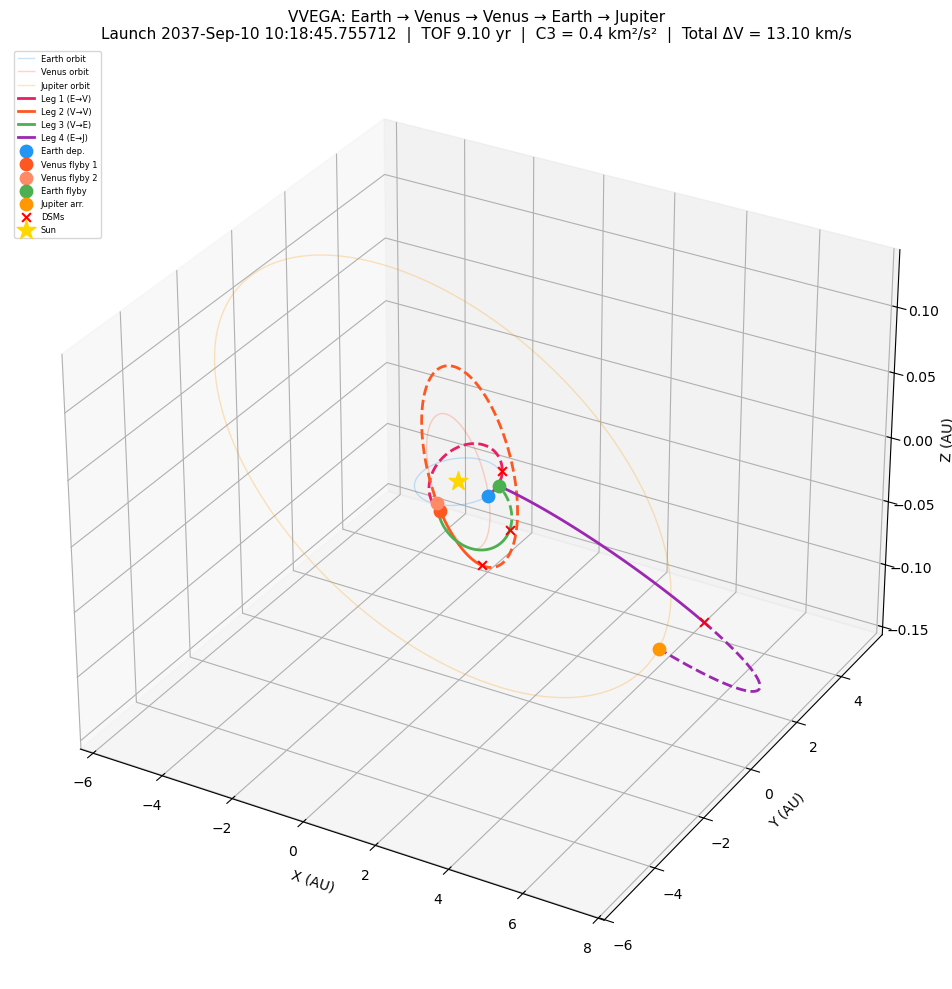

Saved: output/05_trajectory_vvega.png
Saved: output/05_trajectory_vvega.gif


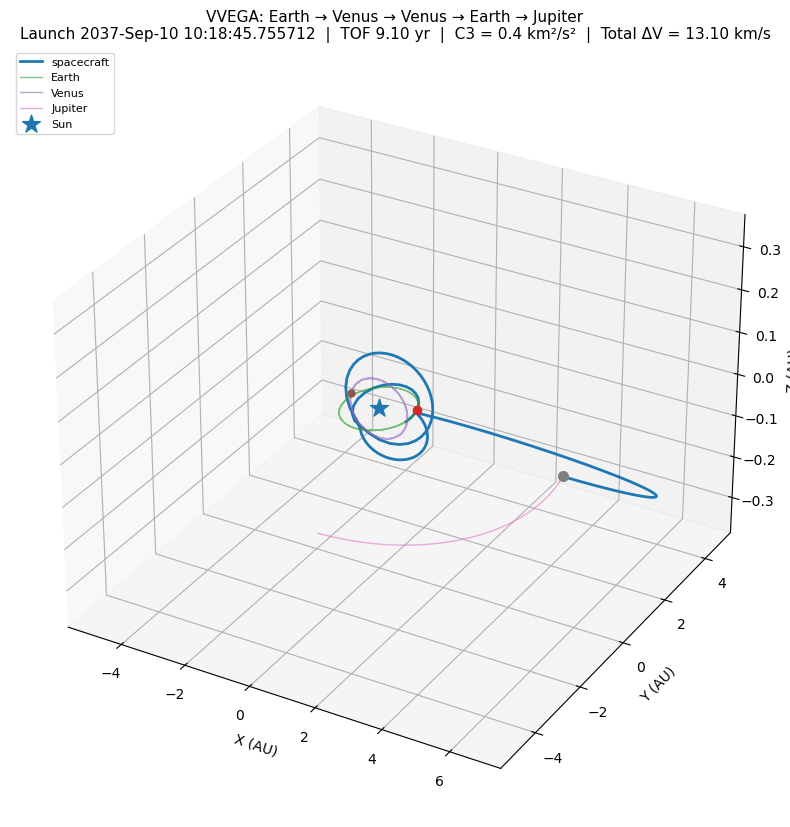

In [6]:
# %% Cell 6 — Trajectory plot (static PNG)
t0_mjd = t0_mjd2000
T_legs = [T1, T2, T3, T4]

# --- Departure state ---
r_dep, v_dep_planet = seq[0].eph(pk.epoch(t0_mjd, 'mjd2000'))
theta = 2 * np.pi * best_x[1]
phi = np.arccos(2 * best_x[2] - 1) - np.pi / 2
Vinfx = vinf_dep_ms * np.cos(phi) * np.cos(theta)
Vinfy = vinf_dep_ms * np.cos(phi) * np.sin(theta)
Vinfz = vinf_dep_ms * np.sin(phi)
v0 = [v_dep_planet[0] + Vinfx, v_dep_planet[1] + Vinfy, v_dep_planet[2] + Vinfz]

# --- Build leg data ---
enc_epochs = [t0_mjd]
for t_leg in T_legs:
    enc_epochs.append(enc_epochs[-1] + t_leg)

r_enc = []
v_enc_planet = []
for i, ep_mjd in enumerate(enc_epochs):
    idx = min(i, len(seq) - 1)
    r_tmp, v_tmp = seq[idx].eph(pk.epoch(ep_mjd, 'mjd2000'))
    r_enc.append(r_tmp)
    v_enc_planet.append(v_tmp)

legs_data = []
r_start = r_dep
v_start = v0

for leg_idx in range(len(T_legs)):
    eta = etas[leg_idx]
    dt_leg = T_legs[leg_idx] * 86400.0
    dt_pre = eta * dt_leg
    dt_post = (1 - eta) * dt_leg
    
    r_dsm, v_dsm = propagate_lagrangian(r_start, v_start, dt_pre, pk.MU_SUN)
    r_next = r_enc[leg_idx + 1]
    lamb = pk.lambert_problem(r_dsm, r_next, dt_post, pk.MU_SUN)
    v_post_dsm = lamb.get_v1()[0]
    v_arr = lamb.get_v2()[0]
    
    legs_data.append({
        'r_start': r_start, 'v_start': v_start,
        'dt_pre': dt_pre, 'r_dsm': r_dsm,
        'v_post_dsm': v_post_dsm, 'dt_post': dt_post,
        'r_end': r_next, 'v_arr': v_arr,
    })
    
    if leg_idx < len(T_legs) - 1:
        dt_next_leg = T_legs[leg_idx + 1] * 86400.0
        r_next_next = r_enc[leg_idx + 2]
        lamb_next = pk.lambert_problem(r_next, r_next_next, dt_next_leg, pk.MU_SUN)
        r_start = r_next
        v_start = lamb_next.get_v1()[0]

# --- Static plot ---
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

n_pts = 100

# Planet orbits
for planet, color, label in [(seq[0], '#2196F3', 'Earth orbit'),
                              (seq[1], '#FF5722', 'Venus orbit'),
                              (seq[4], '#FF9800', 'Jupiter orbit')]:
    period = planet.compute_period(pk.epoch(t0_mjd, 'mjd2000'))
    t_orb = np.linspace(0, period, 200)
    xo, yo, zo = [], [], []
    for dt in t_orb:
        r, _ = planet.eph(pk.epoch(t0_mjd + dt/86400.0, 'mjd2000'))
        xo.append(r[0]/AU); yo.append(r[1]/AU); zo.append(r[2]/AU)
    ax.plot(xo, yo, zo, color=color, alpha=0.25, linewidth=1, label=label)

# Trajectory legs
leg_colors = ['#E91E63', '#FF5722', '#4CAF50', '#9C27B0']
leg_labels = ['Leg 1 (E→V)', 'Leg 2 (V→V)', 'Leg 3 (V→E)', 'Leg 4 (E→J)']

for i, (ld, col, lab) in enumerate(zip(legs_data, leg_colors, leg_labels)):
    arc_x, arc_y, arc_z = [], [], []
    for frac in np.linspace(0, 1, n_pts):
        r, _ = propagate_lagrangian(ld['r_start'], ld['v_start'], frac * ld['dt_pre'], pk.MU_SUN)
        arc_x.append(r[0]/AU); arc_y.append(r[1]/AU); arc_z.append(r[2]/AU)
    ax.plot(arc_x, arc_y, arc_z, color=col, linewidth=2, label=lab)
    
    arc_x, arc_y, arc_z = [], [], []
    for frac in np.linspace(0, 1, n_pts):
        r, _ = propagate_lagrangian(ld['r_dsm'], ld['v_post_dsm'], frac * ld['dt_post'], pk.MU_SUN)
        arc_x.append(r[0]/AU); arc_y.append(r[1]/AU); arc_z.append(r[2]/AU)
    ax.plot(arc_x, arc_y, arc_z, color=col, linewidth=2, linestyle='--')
    
    ax.scatter([ld['r_dsm'][0]/AU], [ld['r_dsm'][1]/AU], [ld['r_dsm'][2]/AU],
               s=40, c='red', marker='x', zorder=5)

# Encounter markers
enc_labels = ['Earth dep.', 'Venus flyby 1', 'Venus flyby 2', 'Earth flyby', 'Jupiter arr.']
enc_colors = ['#2196F3', '#FF5722', '#FF8A65', '#4CAF50', '#FF9800']
for r_e, lab, col in zip(r_enc, enc_labels, enc_colors):
    ax.scatter([r_e[0]/AU], [r_e[1]/AU], [r_e[2]/AU],
               s=80, c=col, marker='o', label=lab, zorder=5)

ax.scatter([], [], [], s=40, c='red', marker='x', label='DSMs')
ax.scatter([0], [0], [0], s=200, c='gold', marker='*', label='Sun', zorder=10)

ax.set_xlabel('X (AU)'); ax.set_ylabel('Y (AU)'); ax.set_zlabel('Z (AU)')
ax.legend(fontsize=6, loc='upper left')
ax.set_title(f'VVEGA: Earth → Venus → Venus → Earth → Jupiter\n'
             f'Launch {launch_epoch}  |  TOF {total_tof/365.25:.2f} yr  |  '
             f'C3 = {c3_dep:.1f} km²/s²  |  Total ΔV = {best_f/1000:.2f} km/s',
             fontsize=11)

plt.tight_layout()
plt.savefig('output/05_trajectory_vvega.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: output/05_trajectory_vvega.png")

# %% Cell 6b — Animated GIF
from matplotlib.animation import FuncAnimation, PillowWriter

fps = 12
days_per_frame = 12
max_frames = 500

# Segment boundaries (cumulative seconds)
seg_bounds = [0.0]
for ld in legs_data:
    seg_bounds.append(seg_bounds[-1] + ld['dt_pre'])
    seg_bounds.append(seg_bounds[-1] + ld['dt_post'])

t_total = seg_bounds[-1]
seconds_per_frame = days_per_frame * 86400.0
n_frames = int(min(max_frames, np.ceil(t_total / seconds_per_frame))) + 1
t_grid = np.linspace(0.0, t_total, n_frames)

xs_sc = np.zeros(n_frames); ys_sc = np.zeros(n_frames); zs_sc = np.zeros(n_frames)
xe = np.zeros(n_frames); ye = np.zeros(n_frames); ze = np.zeros(n_frames)
xv = np.zeros(n_frames); yv = np.zeros(n_frames); zv = np.zeros(n_frames)
xjp = np.zeros(n_frames); yjp = np.zeros(n_frames); zjp = np.zeros(n_frames)

for k, t in enumerate(t_grid):
    for seg_idx in range(len(seg_bounds) - 1):
        if t <= seg_bounds[seg_idx + 1] or seg_idx == len(seg_bounds) - 2:
            break
    
    leg_idx = seg_idx // 2
    is_post_dsm = seg_idx % 2 == 1
    dt_local = t - seg_bounds[seg_idx]
    
    ld = legs_data[leg_idx]
    if is_post_dsm:
        r, _ = propagate_lagrangian(ld['r_dsm'], ld['v_post_dsm'], dt_local, pk.MU_SUN)
    else:
        r, _ = propagate_lagrangian(ld['r_start'], ld['v_start'], dt_local, pk.MU_SUN)
    
    xs_sc[k] = r[0]/AU; ys_sc[k] = r[1]/AU; zs_sc[k] = r[2]/AU

    abs_mjd = t0_mjd + t / 86400.0
    ep = pk.epoch(abs_mjd, 'mjd2000')
    re, _ = seq[0].eph(ep); rv, _ = seq[1].eph(ep); rj, _ = seq[4].eph(ep)
    xe[k] = re[0]/AU; ye[k] = re[1]/AU; ze[k] = re[2]/AU
    xv[k] = rv[0]/AU; yv[k] = rv[1]/AU; zv[k] = rv[2]/AU
    xjp[k] = rj[0]/AU; yjp[k] = rj[1]/AU; zjp[k] = rj[2]/AU

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

(sc_line,) = ax.plot([], [], [], linewidth=2, label='spacecraft')
(sc_dot,)  = ax.plot([], [], [], marker='o', markersize=5, linestyle='')
(tr_e,) = ax.plot([], [], [], linewidth=1, alpha=0.6, label='Earth')
(pt_e,) = ax.plot([], [], [], marker='o', markersize=6, linestyle='')
(tr_v,) = ax.plot([], [], [], linewidth=1, alpha=0.6, label='Venus')
(pt_v,) = ax.plot([], [], [], marker='o', markersize=5, linestyle='')
(tr_j,) = ax.plot([], [], [], linewidth=1, alpha=0.6, label='Jupiter')
(pt_j,) = ax.plot([], [], [], marker='o', markersize=7, linestyle='')

ax.scatter([0], [0], [0], s=180, marker='*', label='Sun', zorder=10)
ax.set_xlabel('X (AU)'); ax.set_ylabel('Y (AU)'); ax.set_zlabel('Z (AU)')
ax.legend(fontsize=8, loc='upper left')
ax.set_title(f'VVEGA: Earth → Venus → Venus → Earth → Jupiter\n'
             f'Launch {launch_epoch}  |  TOF {total_tof/365.25:.2f} yr  |  '
             f'C3 = {c3_dep:.1f} km²/s²  |  Total ΔV = {best_f/1000:.2f} km/s',
             fontsize=11)

pad = 0.25
allx = np.concatenate([xs_sc, xe, xv, xjp])
ally = np.concatenate([ys_sc, ye, yv, yjp])
allz = np.concatenate([zs_sc, ze, zv, zjp])
ax.set_xlim(allx.min()-pad, allx.max()+pad)
ax.set_ylim(ally.min()-pad, ally.max()+pad)
ax.set_zlim(allz.min()-pad, allz.max()+pad)

trail_len = 80

def init():
    for obj in [sc_line, sc_dot, tr_e, pt_e, tr_v, pt_v, tr_j, pt_j]:
        obj.set_data([], [])
        obj.set_3d_properties([])
    return sc_line, sc_dot, tr_e, pt_e, tr_v, pt_v, tr_j, pt_j

def update(i):
    sc_line.set_data(xs_sc[:i+1], ys_sc[:i+1])
    sc_line.set_3d_properties(zs_sc[:i+1])
    sc_dot.set_data([xs_sc[i]], [ys_sc[i]])
    sc_dot.set_3d_properties([zs_sc[i]])
    j0 = max(0, i - trail_len)
    tr_e.set_data(xe[j0:i+1], ye[j0:i+1]); tr_e.set_3d_properties(ze[j0:i+1])
    pt_e.set_data([xe[i]], [ye[i]]); pt_e.set_3d_properties([ze[i]])
    tr_v.set_data(xv[j0:i+1], yv[j0:i+1]); tr_v.set_3d_properties(zv[j0:i+1])
    pt_v.set_data([xv[i]], [yv[i]]); pt_v.set_3d_properties([zv[i]])
    tr_j.set_data(xjp[j0:i+1], yjp[j0:i+1]); tr_j.set_3d_properties(zjp[j0:i+1])
    pt_j.set_data([xjp[i]], [yjp[i]]); pt_j.set_3d_properties([zjp[i]])
    return sc_line, sc_dot, tr_e, pt_e, tr_v, pt_v, tr_j, pt_j

anim = FuncAnimation(fig, update, frames=n_frames, init_func=init,
                     interval=1000/fps, blit=True)
anim.save('output/05_trajectory_vvega.gif', writer=PillowWriter(fps=fps))
print("Saved: output/05_trajectory_vvega.gif")
plt.show()

In [ ]:
# %% Cell 7 — Convergence diagnostics
print("Solution vector breakdown (4-leg, 18 variables):")
print(f"  t0 (mjd2000):       {best_x[0]:.2f} → {launch_epoch}")
print(f"  u (V∞ dir):          {best_x[1]:.4f}")
print(f"  v (V∞ dir):          {best_x[2]:.4f}")
print(f"  V∞ dep:              {best_x[3]:.1f} m/s = {best_x[3]/1000:.3f} km/s")
print(f"  η1 (DSM1):           {best_x[4]:.4f}")
print(f"  T1 (E→V days):       {best_x[5]:.1f}")
print(f"  β2 (Venus1 fb):      {best_x[6]:.4f}")
print(f"  rp2/rV2 (Venus1):    {best_x[7]:.4f}")
print(f"  η2 (DSM2):           {best_x[8]:.4f}")
print(f"  T2 (V→V days):       {best_x[9]:.1f}")
print(f"  β3 (Venus2 fb):      {best_x[10]:.4f}")
print(f"  rp3/rV3 (Venus2):    {best_x[11]:.4f}")
print(f"  η3 (DSM3):           {best_x[12]:.4f}")
print(f"  T3 (V→E days):       {best_x[13]:.1f}")
print(f"  β4 (Earth fb):       {best_x[14]:.4f}")
print(f"  rp4/rV4 (Earth):     {best_x[15]:.4f}")
print(f"  η4 (DSM4):           {best_x[16]:.4f}")
print(f"  T4 (E→J days):       {best_x[17]:.1f}")

print("\nBound checks:")
print(f"  T1: 100 ≤ {best_x[5]:.0f} ≤ 400    {'⚠ AT BOUND' if best_x[5] < 101 or best_x[5] > 399 else '✓'}")
print(f"  T2: 100 ≤ {best_x[9]:.0f} ≤ 600    {'⚠ AT BOUND' if best_x[9] < 101 or best_x[9] > 599 else '✓'}")
print(f"  T3: 100 ≤ {best_x[13]:.0f} ≤ 600   {'⚠ AT BOUND' if best_x[13] < 101 or best_x[13] > 599 else '✓'}")
print(f"  T4: 500 ≤ {best_x[17]:.0f} ≤ 2200  {'⚠ AT BOUND' if best_x[17] < 501 or best_x[17] > 2199 else '✓'}")
vinf_kms = best_x[3] / 1000
print(f"  V∞: 0.5 ≤ {vinf_kms:.2f} ≤ 6.0 km/s  {'⚠ AT BOUND' if vinf_kms < 0.51 or vinf_kms > 5.99 else '✓'}")


Solution vector breakdown (4-leg, 18 variables):
  t0 (mjd2000):       13767.43 → 2037-Sep-10 10:18:45.755712
  u (V∞ dir):          0.9316
  v (V∞ dir):          0.3485
  V∞ dep:              620.1 m/s = 0.620 km/s
  η1 (DSM1):           0.2250
  T1 (E→V days):       219.7
  β2 (Venus1 fb):      4.8433
  rp2/rV2 (Venus1):    1.4328
  η2 (DSM2):           0.1000
  T2 (V→V days):       444.9
  β3 (Venus2 fb):      1.3140
  rp3/rV3 (Venus2):    4.6730
  η3 (DSM3):           0.7310
  T3 (V→E days):       457.7
  β4 (Earth fb):       -1.4984
  rp4/rV4 (Earth):     1.1000
  η4 (DSM4):           0.2648
  T4 (E→J days):       2200.0

Bound checks:
  T1: 100 ≤ 220 ≤ 400    ✓
  T2: 100 ≤ 445 ≤ 600    ✓
  T3: 100 ≤ 458 ≤ 600   ✓
  T4: 500 ≤ 2200 ≤ 2200  ⚠ AT BOUND
  V∞: 0.5 ≤ 0.62 ≤ 6.0 km/s  ✓
